In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import os, zipfile, random
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils import class_weight

# Seed & GPU
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TF:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))

# ============================================================
# TỰ ĐỘNG XÁC ĐỊNH MÔI TRƯỜNG & TẢI DỮ LIỆU
# ============================================================
# Nếu đang chạy trên Kaggle, dataset path thường là /kaggle/input/<dataset_name>
KAGGLE_INPUT_DIR = "/kaggle/input"
LOCAL_EXTRACT_DIR = "/kaggle/working/dataset_unzipped" if os.path.exists("/kaggle") else "/content/dataset_unzipped"

# Tên file zip (đổi nếu cần)
ZIP_FILENAME = "Harvesting_Dataset.zip"  # Đặt tên file zip của bạn

# Kiểm tra xem file zip đã có sẵn trong Kaggle input chưa
zip_path = None
if os.path.exists(KAGGLE_INPUT_DIR):
    # Tìm file zip trong tất cả thư mục con của /kaggle/input
    for root, dirs, files in os.walk(KAGGLE_INPUT_DIR):
        if ZIP_FILENAME in files:
            zip_path = os.path.join(root, ZIP_FILENAME)
            break

if zip_path is None:
    # Không tìm thấy -> tải từ Google Drive bằng gdown
    import gdown
    DRIVE_FILE_ID = "11OP0vbp2vJZxhkD0K4DAFyNSHtOASyr3"  # ID file của bạn
    print("⏳ Không tìm thấy file zip trong Kaggle input. Đang tải từ Google Drive...")
    url = f"https://drive.google.com/uc?id={DRIVE_FILE_ID}"
    zip_path = "/kaggle/working/temp.zip" if os.path.exists("/kaggle") else "/content/temp.zip"
    gdown.download(url, zip_path, quiet=False)
else:
    print(f"✅ Tìm thấy file zip: {zip_path}")

# Giải nén nếu chưa có
if not os.path.exists(LOCAL_EXTRACT_DIR):
    print("⏳ Đang giải nén dữ liệu...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(LOCAL_EXTRACT_DIR)
    # Xoá file zip tạm để tiết kiệm dung lượng (tuỳ chọn)
    if "temp.zip" in zip_path:
        os.remove(zip_path)
    print("✅ Giải nén xong!")
else:
    print("✅ Dữ liệu đã được giải nén sẵn.")

# Tìm đúng folder chứa Cut/Keep
target_folders = ["Cut", "Keep", "cut", "keep"]
DATA_DIR = LOCAL_EXTRACT_DIR
found = False
for root, dirs, files in os.walk(LOCAL_EXTRACT_DIR):
    if any(f in dirs for f in target_folders):
        DATA_DIR = root
        found = True
        break

print(f"📂 DATA_DIR: {DATA_DIR}")
print("Subfolders:", os.listdir(DATA_DIR))

2026-05-10 10:15:56.730078: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778408157.025008      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778408157.116225      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778408157.863570      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778408157.863631      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778408157.863635      57 computation_placer.cc:177] computation placer alr

TF: 2.19.0
GPUs: []


2026-05-10 10:16:27.471937: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


⏳ Không tìm thấy file zip trong Kaggle input. Đang tải từ Google Drive...


Downloading...
From (original): https://drive.google.com/uc?id=11OP0vbp2vJZxhkD0K4DAFyNSHtOASyr3
From (redirected): https://drive.google.com/uc?id=11OP0vbp2vJZxhkD0K4DAFyNSHtOASyr3&confirm=t&uuid=3290dda7-9196-4208-a343-ad76967058aa
To: /kaggle/working/temp.zip
100%|██████████| 4.84G/4.84G [00:49<00:00, 98.3MB/s]


⏳ Đang giải nén dữ liệu...
✅ Giải nén xong!
📂 DATA_DIR: /kaggle/working/dataset_unzipped/Harvesting_Dataset
Subfolders: ['Keep', 'Cut']


# EDA

Thư mục gốc: ['Keep', 'Cut']
Số lượng ảnh "Cut": 1143
Số lượng ảnh "Keep": 1542


/tmp/ipykernel_57/2222807626.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=classes, y=[num_cut, num_keep], palette='pastel')


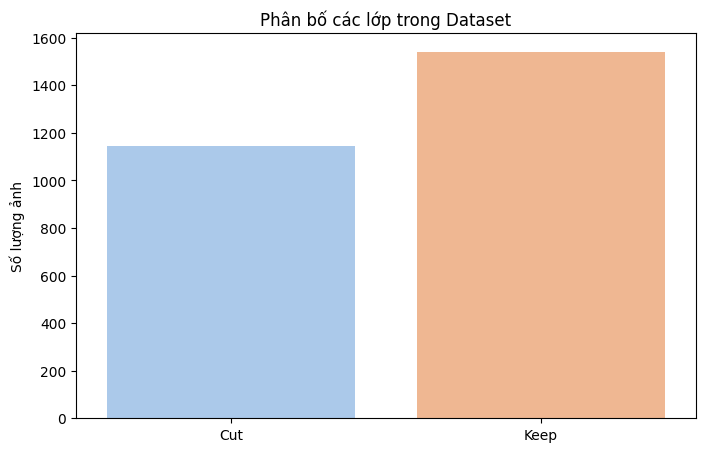

==================== Dữ liệu lớp: Cut ====================
Ảnh: 26_image_998.jpg | Kích thước (H, W, C): (1968, 2157, 3)
Ảnh: 16_image_363.jpg | Kích thước (H, W, C): (2547, 1709, 3)
Ảnh: 12_image_256.jpg | Kích thước (H, W, C): (2652, 3000, 3)
Ảnh: 22_image_646.jpg | Kích thước (H, W, C): (2634, 3024, 3)
Ảnh: 2_image_29.jpg | Kích thước (H, W, C): (2207, 3000, 3)


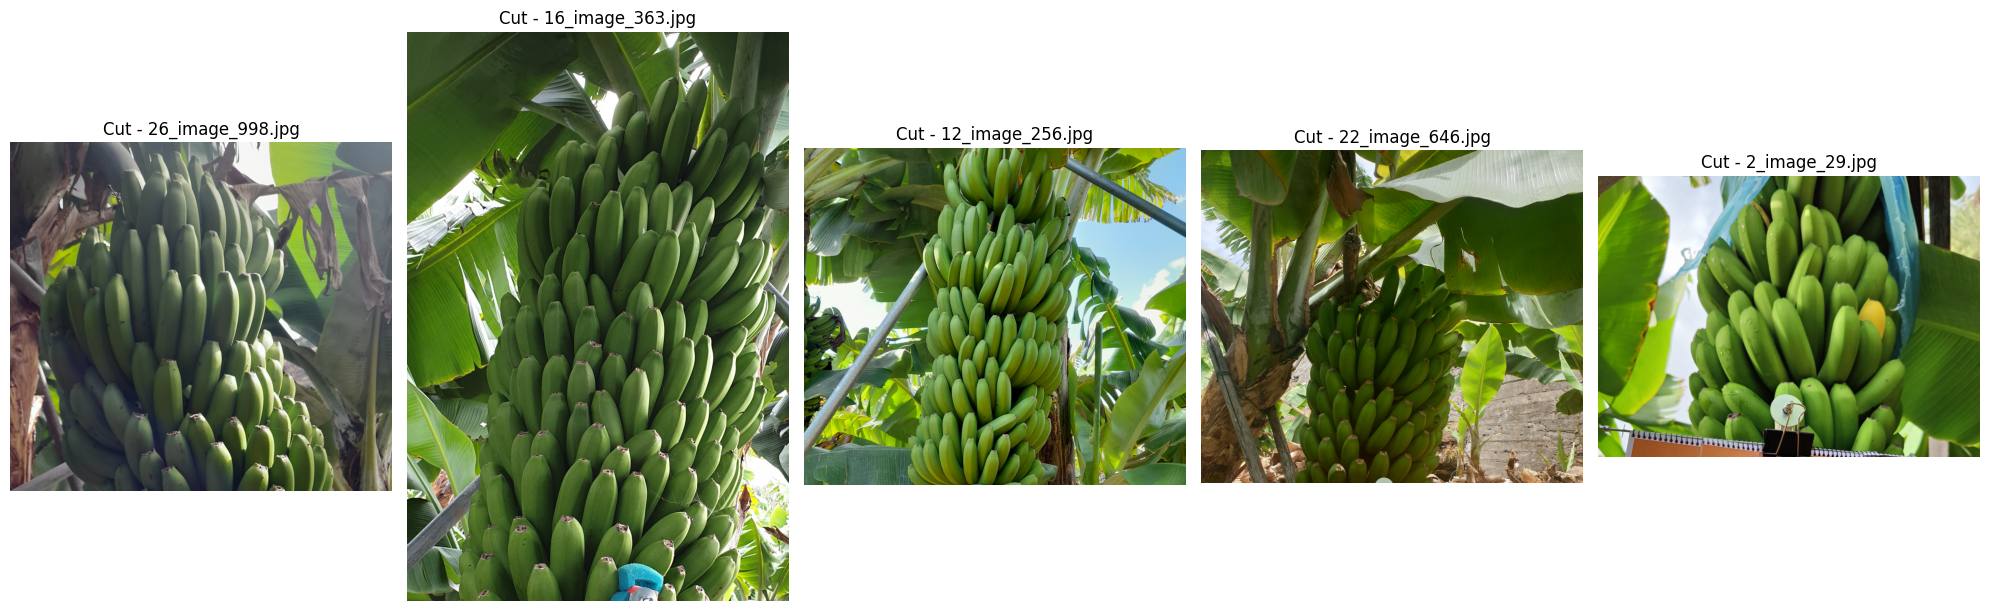

==================== Dữ liệu lớp: Keep ====================
Ảnh: 19_image_785.jpg | Kích thước (H, W, C): (2599, 3000, 3)
Ảnh: 3_image_121.jpg | Kích thước (H, W, C): (2814, 3000, 3)
Ảnh: 12_image_560.jpg | Kích thước (H, W, C): (2320, 3000, 3)
Ảnh: 24_image_1113.jpg | Kích thước (H, W, C): (2249, 2018, 3)
Ảnh: 24_image_1129.jpg | Kích thước (H, W, C): (2733, 3000, 3)


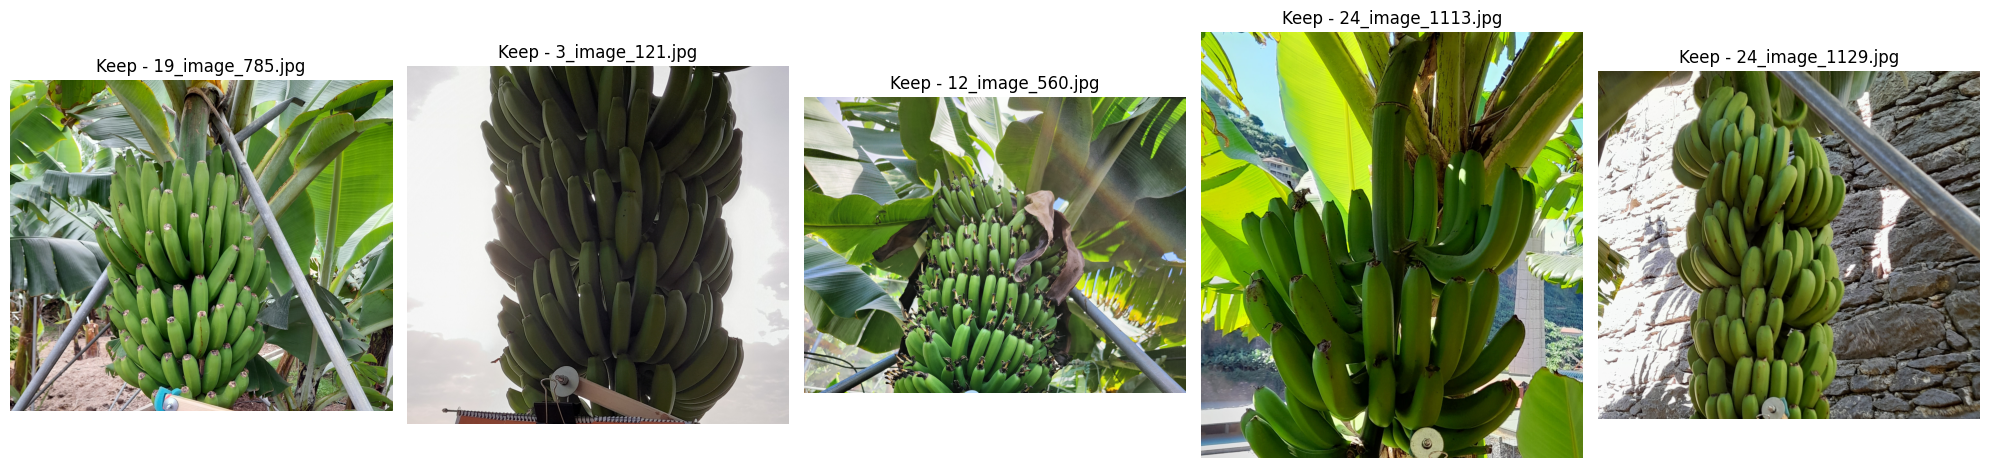

In [3]:
import os 
import matplotlib.pyplot as plt 
import seaborn as sns
import random 
import cv2 

# Đường dẫn bộ dữ liệu
parent_path = '/kaggle/working/dataset_unzipped/Harvesting_Dataset'
classes = ['Cut', 'Keep']

# 1. Thống kê số lượng ảnh
num_cut = len(os.listdir(os.path.join(parent_path, 'Cut')))
num_keep = len(os.listdir(os.path.join(parent_path, 'Keep')))

print(f"Thư mục gốc: {os.listdir(parent_path)}")
print(f'Số lượng ảnh "Cut": {num_cut}')
print(f'Số lượng ảnh "Keep": {num_keep}')

# Vẽ biểu đồ phân bố lớp
plt.figure(figsize=(8, 5))
sns.barplot(x=classes, y=[num_cut, num_keep], palette='pastel')
plt.title('Phân bố các lớp trong Dataset')
plt.ylabel('Số lượng ảnh')
plt.show()

# 2. Hàm hiển thị ảnh mẫu ngẫu nhiên
def visualize_images(kind, num_images=5):
    print("="*20 + f" Dữ liệu lớp: {kind} " + "="*20)
    
    # Lấy danh sách file và chọn ngẫu nhiên
    folder_path = os.path.join(parent_path, kind)
    filename_images = random.sample(os.listdir(folder_path), num_images)
    
    plt.figure(figsize=(20, 10))
    
    for i, name in enumerate(filename_images):
        src = os.path.join(folder_path, name)
        img = cv2.imread(src)
        # Chuyển sang RGB để hiển thị đúng với Matplotlib
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        print(f"Ảnh: {name} | Kích thước (H, W, C): {img.shape}")
        
        plt.subplot(1, num_images, i + 1)
        plt.imshow(img_rgb)
        plt.title(f"{kind} - {name}")
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()

# Gọi hàm để xem thử
visualize_images('Cut', 5)
visualize_images('Keep', 5)

## comments : 
* skewed distribution
* Dữ liệu có độ phân giải cao 

In [4]:
# ==========================================
# BƯỚC 1: DATA SPLIT — Đồng bộ với DL pipeline
# ==========================================
import os
import cv2
import numpy as np
from sklearn.model_selection import train_test_split
from scipy.stats import skew
from skimage.feature import hog, local_binary_pattern
from sklearn.utils import class_weight
import albumentations as A          # pip install albumentations

SEED = 42
DATA_DIR = "/kaggle/working/dataset_unzipped/Harvesting_Dataset"                   # thư mục chứa Cut/ và Keep/

# --- Augmentation pipeline (giống DL friend) ---
train_aug = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.ShiftScaleRotate(
        shift_limit=0.2,
        scale_limit=0.2,
        rotate_limit=20,
        border_mode=cv2.BORDER_REFLECT_101,
        p=0.7
    ),
])

def augment_image(img_rgb, aug_pipeline, n_aug=3):
    """Trả về ảnh gốc + n_aug biến thể đã augment."""
    results = [img_rgb]
    for _ in range(n_aug):
        augmented = aug_pipeline(image=img_rgb)["image"]
        results.append(augmented)
    return results

def load_dataset_paths(parent_path, kind_list=["Cut", "Keep"]):
    """Trả về list (path, label) cho toàn bộ dataset."""
    paths, labels = [], []
    for idx, kind in enumerate(kind_list):
        folder = os.path.join(parent_path, kind)
        for fname in os.listdir(folder):
            if fname.lower().endswith((".jpg", ".png", ".jpeg")):
                paths.append(os.path.join(folder, fname))
                labels.append(idx)
    return np.array(paths), np.array(labels)

# 1. Load toàn bộ paths + labels
all_paths, all_labels = load_dataset_paths(DATA_DIR)

# 2. Tách train 70% / temp 30% — stratified (giữ tỉ lệ class)
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    all_paths, all_labels,
    test_size=0.30,
    stratify=all_labels,
    random_state=SEED
)

# 3. Chia temp thành val 15% / test 15% - shuffle 
indices = np.arange(len(temp_paths))
np.random.seed(SEED)
np.random.shuffle(indices)
temp_paths  = temp_paths[indices]
temp_labels = temp_labels[indices]
mid = len(temp_paths) // 2
val_paths,  val_labels  = temp_paths[:mid],  temp_labels[:mid]
test_paths, test_labels = temp_paths[mid:],  temp_labels[mid:]

print(f"Train : {len(train_paths)} ảnh gốc")
print(f"Val   : {len(val_paths)}   (Class 0: {np.sum(val_labels==0)}, Class 1: {np.sum(val_labels==1)})")
print(f"Test  : {len(test_paths)}  (Class 0: {np.sum(test_labels==0)}, Class 1: {np.sum(test_labels==1)})")

Train : 1879 ảnh gốc
Val   : 403   (Class 0: 182, Class 1: 221)
Test  : 403  (Class 0: 161, Class 1: 242)


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


# Feature extractor

In [5]:
import numpy as np
import cv2
import os
from skimage.feature import hog, local_binary_pattern
from scipy.stats import skew
from sklearn.decomposition import PCA

In [6]:
# ==========================================
# BƯỚC 2: FEATURE EXTRACTION (giữ nguyên FeatureExtractor của bạn)
# ==========================================

class FeatureExtractor:
    def __init__(self, resize_size=(256, 256)):
        self.resize_size = resize_size

    def _preprocess(self, img_rgb):
        img_resized = cv2.resize(img_rgb, self.resize_size)
        gray = cv2.cvtColor(img_resized, cv2.COLOR_RGB2GRAY)
        return img_resized, gray

    def get_hog(self, gray):
        return hog(gray, orientations=9, pixels_per_cell=(16, 16),
                   cells_per_block=(2, 2), visualize=False)

    def get_lbp(self, gray):
        radius, n_points = 3, 24
        lbp = local_binary_pattern(gray, n_points, radius, method="uniform")
        hist, _ = np.histogram(lbp.ravel(),
                               bins=np.arange(0, n_points + 3),
                               range=(0, n_points + 2))
        hist = hist.astype("float")
        hist /= (hist.sum() + 1e-7)
        return hist

    def get_color_histograms(self, img_rgb):
        hist_features = []
        for i in range(3):
            hist = cv2.calcHist([img_rgb], [i], None, [32], [0, 256])
            cv2.normalize(hist, hist)
            hist_features.extend(hist.flatten())
        return np.array(hist_features)

    def get_color_moments(self, img_rgb):
        moments = []
        for i in range(3):
            ch = img_rgb[:, :, i]
            moments += [np.mean(ch), np.std(ch), skew(ch.flatten())]
        return np.array(moments)

    def extract_all(self, img_rgb, use_color=True):
        img_res, gray = self._preprocess(img_rgb)
        features = np.hstack([self.get_hog(gray), self.get_lbp(gray)])
        if use_color:
            features = np.hstack([features,
                                   self.get_color_histograms(img_res),
                                   self.get_color_moments(img_res)])
        return features


def extract_split(paths, labels, extractor, use_color=True,
                  apply_aug=False, aug_pipeline=None, n_aug=3):
    """
    Trích xuất feature cho một split.
    - apply_aug=True  → dùng cho train (gốc + n_aug biến thể)
    - apply_aug=False → dùng cho val/test (chỉ ảnh gốc)
    """
    X, y = [], []
    pca = PCA(n_components=500)
    
    for path, label in zip(paths, labels):
        img_bgr = cv2.imread(path)
        if img_bgr is None:
            continue
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

        imgs = augment_image(img_rgb, aug_pipeline, n_aug) if apply_aug else [img_rgb]

        for img in imgs:
            X.append(extractor.extract_all(img, use_color=use_color))
            y.append(label)

    return np.array(X), np.array(y)


extractor = FeatureExtractor(resize_size=(256 , 256))
USE_COLOR  = True
N_AUG      = 3          # mỗi ảnh train → 1 gốc + 3 aug = 4 samples

print("Extracting train (with augmentation)...")
X_train, y_train = extract_split(
    train_paths, train_labels, extractor,
    use_color=USE_COLOR, apply_aug=True,
    aug_pipeline=train_aug, n_aug=N_AUG
)

print("Extracting val...")
X_val, y_val = extract_split(
    val_paths, val_labels, extractor,
    use_color=USE_COLOR, apply_aug=False
)

print("Extracting test...")
X_test, y_test = extract_split(
    test_paths, test_labels, extractor,
    use_color=USE_COLOR, apply_aug=False
)

print(f"\nX_train: {X_train.shape} | y_train: {y_train.shape}")
print(f"X_val  : {X_val.shape}   | y_val  : {y_val.shape}")
print(f"X_test : {X_test.shape}  | y_test : {y_test.shape}")

# Class weights (tính trên y_train sau augmentation)
cw = class_weight.compute_class_weight("balanced",
                                        classes=np.unique(y_train),
                                        y=y_train)
class_weights_dict = dict(enumerate(cw))
print(f"⚖️  Class Weights: {class_weights_dict}")

Extracting train (with augmentation)...
Extracting val...
Extracting test...

X_train: (7516, 8231) | y_train: (7516,)
X_val  : (403, 8231)   | y_val  : (403,)
X_test : (403, 8231)  | y_test : (403,)
⚖️  Class Weights: {0: np.float64(1.174375), 1: np.float64(0.870713623725672)}


In [7]:
from sklearn.decomposition import PCA

pca = PCA(n_components=100)
# giảm chièu dữ liệu vì lí do 8200 features 
X_train_pca = pca.fit_transform(X_train)
X_val_pca = pca.transform(X_val)
X_test_pca = pca.transform(X_test)

In [8]:
X_train_pca.shape

(7516, 100)

In [9]:
import joblib

joblib.dump(pca, "pca_reducer.pkl")

pca = joblib.load("pca_reducer.pkl")

# transform dữ liệu mới
print(sum(X_train_pca - pca.transform(X_train))**2)

[4.29660881e-24 3.94556276e-21 8.23559120e-22 4.31532391e-21
 1.75846417e-22 2.93554554e-23 6.63506196e-25 2.46878950e-25
 9.08799378e-25 3.19657454e-24 1.93552570e-24 2.27024325e-25
 1.39031189e-25 2.16515087e-25 2.92735564e-25 1.94040604e-24
 5.53909896e-25 5.32127016e-26 6.16664910e-26 2.24254392e-24
 1.45082257e-25 2.21429431e-23 5.52795860e-25 1.26966558e-24
 4.10288606e-24 4.57780111e-25 1.48623841e-27 4.75834571e-25
 7.76254727e-25 6.92397928e-26 1.08711227e-24 2.33263216e-25
 7.42238341e-24 1.35899544e-23 1.00336654e-23 8.25339365e-23
 1.81840130e-24 1.13573029e-24 1.81544809e-23 3.62550434e-25
 3.03918336e-24 1.62841883e-25 2.54413710e-26 5.81076883e-24
 6.17476840e-24 6.27276585e-28 1.06565545e-24 1.98303033e-23
 5.63267954e-25 1.03621375e-24 8.12243687e-25 5.42818639e-27
 4.05196303e-25 7.24250809e-24 4.55950224e-24 5.68215406e-27
 5.08204857e-25 3.47255592e-25 7.41820860e-25 1.14378257e-23
 8.60744926e-25 1.21514973e-26 1.94183573e-23 5.96902429e-24
 8.67308335e-24 1.977158

In [12]:
# Normalize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_pca)
X_val = scaler.transform(X_val_pca)
X_test = scaler.transform(X_test_pca)
print(f"  ✓ Features normalized (StandardScaler)")

 
# Class weights
cw = class_weight.compute_class_weight(
    "balanced", classes=np.unique(y_train), y=y_train
)
class_weights_dict = dict(enumerate(cw))
print(f"  ⚖️  Class Weights: {class_weights_dict}")
 

  ✓ Features normalized (StandardScaler)
  ⚖️  Class Weights: {0: np.float64(1.174375), 1: np.float64(0.870713623725672)}


In [13]:
import joblib

joblib.dump(scaler, "scaler.pkl")

scaler = joblib.load("scaler.pkl")

# Models

In [11]:
import os
import cv2
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
import joblib
 
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import (
    RandomForestClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, f1_score, confusion_matrix, accuracy_score, roc_auc_score
)
from sklearn.utils import class_weight
from scipy.stats import skew
from skimage.feature import hog, local_binary_pattern
import albumentations as A
from xgboost import XGBClassifier
from sklearn.metrics import (
    f1_score, accuracy_score, roc_auc_score,
    precision_score, recall_score          # ← thêm 2 dòng này vào import
)
# import lightgbm as lgb
# from catboost import CatBoostClassifier

In [14]:

 
# ============================================
# BƯỚC 3: MODELS + HYPERPARAMETERS
# ============================================
print("\n" + "="*60)
print("BƯỚC 3: DEFINE MODELS & HYPERPARAMETERS")
print("="*60)
 
pos_ratio = np.sum(y_train == 0) / np.sum(y_train == 1)
 
models = {
    "SVM":               SVC(probability=True, class_weight="balanced", random_state=SEED),
    "Random Forest":     RandomForestClassifier(class_weight="balanced", random_state=SEED, n_jobs=-1),
    "Extra Trees":       ExtraTreesClassifier(class_weight="balanced", random_state=SEED, n_jobs=-1),
    "HistGradient":      HistGradientBoostingClassifier(random_state=SEED, verbose=0, early_stopping=False),
    "KNN":               KNeighborsClassifier(n_jobs=-1),
    "Logistic Reg":      LogisticRegression(class_weight="balanced", max_iter=1000, random_state=SEED, n_jobs=-1),
    "XGBoost":           XGBClassifier(eval_metric="logloss", scale_pos_weight=pos_ratio, 
                                       random_state=SEED, verbosity=0, n_jobs=-1),
    # "LightGBM":          lgb.LGBMClassifier(class_weight="balanced", random_state=SEED,
    #                                         verbose=-1, force_col_wise=True, n_jobs=-1),
    # "CatBoost":          CatBoostClassifier(class_weights=[1, pos_ratio], random_state=SEED,
    #                                         verbose=False, allow_writing_files=False),
}
 
param_grids = {
    "SVM": {
        "C": [0.1, 1, 10],
        "kernel": ["rbf", "linear"],
        "gamma": ["scale", "auto"],
    },
    "Random Forest": {
        "n_estimators": [50, 100, 200],
        "max_depth": [None, 10, 20],
        "min_samples_split": [2, 5],
    },
    "Extra Trees": {
        "n_estimators": [50, 100, 200],
        "max_depth": [None, 10, 20],
    },
    "HistGradient": {
        "learning_rate": [0.01, 0.1],
        "max_iter": [100, 200],
        "max_depth": [5, 10],
    },
    "KNN": {
        "n_neighbors": [3, 5, 7, 9],
        "weights": ["uniform", "distance"],
    },
    "Logistic Reg": {
        "C": [0.01, 0.1, 1, 10],
        "solver": ["lbfgs", "saga"],
    },
    "XGBoost": {
        "n_estimators": [50, 100, 200],
        "learning_rate": [0.01, 0.1],
        "max_depth": [3, 6],
    },
    # "LightGBM": {
    #     "n_estimators": [50, 100, 200],
    #     "learning_rate": [0.01, 0.05, 0.1],
    #     "max_depth": [3, 6, 10],
    #     "num_leaves": [15, 31],
    # },
    # "CatBoost": {
    #     "iterations": [50, 100, 200],
    #     "learning_rate": [0.01, 0.05, 0.1],
    #     "depth": [3, 6, 8],
    # },
}
 
print(f"✅ Defined {len(models)} models")
 


BƯỚC 3: DEFINE MODELS & HYPERPARAMETERS
✅ Defined 7 models


# Train với 1000 features

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=1000)
# giảm chièu dữ liệu vì lí do 8200 features 
X_train_pca = pca.fit_transform(X_train)
X_val_pca = pca.transform(X_val)
X_test_pca = pca.transform(X_test)

In [ ]:
# Normalize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_pca)
X_val_scaled = scaler.transform(X_val_pca)
X_test_scaled = scaler.transform(X_test_pca)
print(f"  ✓ Features normalized (StandardScaler)")

# Class weights
cw = class_weight.compute_class_weight(
    "balanced", classes=np.unique(y_train), y=y_train
)
class_weights_dict = dict(enumerate(cw))
print(f"  ⚖️  Class Weights: {class_weights_dict}")
 

In [36]:
# ============================================
# BƯỚC 4: TRAIN + GRIDSEARCH
# ============================================
print("\n" + "="*60)
print("BƯỚC 4: TRAINING (GridSearchCV + StratifiedKFold)")
print("="*60)


def save_model(model, name: str, output_dir: str):
    """Save trained model to disk."""
    os.makedirs(output_dir, exist_ok=True)
    safe_name = name.lower().replace(" ", "_")
    path = os.path.join(output_dir, f"best_{safe_name}.pkl")
    joblib.dump(model, path)
    return path


def train_models(X_tr, y_tr, X_val, y_val, output_dir):
    """Train all models with GridSearchCV."""
    best_models = {}
    results_summary = []
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)

    for name, model in models.items():
        print(f"\n🚀 Training {name:20s}...", end=' ', flush=True)

        grid = GridSearchCV(
            model, param_grids[name], cv=cv,
            scoring="f1_macro", n_jobs=-1, verbose=0
        )
        grid.fit(X_tr, y_tr)

        best_model = grid.best_estimator_
        best_models[name] = best_model

        # Evaluate on Val
        y_pred_val = best_model.predict(X_val)
        f1_val        = f1_score(y_val, y_pred_val, average="macro")
        acc_val        = accuracy_score(y_val, y_pred_val)
        precision_val  = precision_score(y_val, y_pred_val, average="macro", zero_division=0)  # ← MỚI
        recall_val     = recall_score(y_val, y_pred_val, average="macro", zero_division=0)     # ← MỚI

        try:
            auc_val = roc_auc_score(y_val, best_model.predict_proba(X_val)[:, 1])
        except:
            auc_val = np.nan

        results_summary.append({
            "Model":         name,
            "Best Params":   str(grid.best_params_)[:80],
            "CV f1":         round(grid.best_score_, 4),
            "Val f1":        round(f1_val, 4),
            "Val Precision": round(precision_val, 4),   # ← MỚI
            "Val Recall":    round(recall_val, 4),      # ← MỚI
            "Val Acc":       round(acc_val, 4),
            "Val AUC":       round(auc_val, 4),
        })

        save_path = save_model(best_model, name, output_dir)
        print(f"✅ f1={f1_val:.4f} | prec={precision_val:.4f} | rec={recall_val:.4f} | auc={auc_val:.4f}")

    return best_models, results_summary


OUTPUT_DIR = '/trained_1000'
best_models, results_summary = train_models(X_train_scaled, y_train_scaled, X_val_scaled, y_val_scaled, OUTPUT_DIR)


BƯỚC 4: TRAINING (GridSearchCV + StratifiedKFold) - FEATURES: 1000

🚀 Training SVM                  ... ✅ f1=0.6128 | prec=0.6135 | rec=0.6122 | auc=0.6821

🚀 Training Random Forest        ... ✅ f1=0.6147 | prec=0.6154 | rec=0.6143 | auc=0.6541

🚀 Training Extra Trees          ... ✅ f1=0.6456 | prec=0.6479 | rec=0.6492 | auc=0.6606

🚀 Training HistGradient         ... ✅ f1=0.6194 | prec=0.6264 | rec=0.6192 | auc=0.6766

🚀 Training KNN                  ... ✅ f1=0.5697 | prec=0.5697 | rec=0.5703 | auc=0.5827

🚀 Training Logistic Reg         ... ✅ f1=0.5909 | prec=0.5952 | rec=0.5956 | auc=0.6421

🚀 Training XGBoost              ... ✅ f1=0.6031 | prec=0.6037 | rec=0.6028 | auc=0.6483


# Train với 500 features

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components==500)
# giảm chièu dữ liệu vì lí do 8200 features 
X_train_pca = pca.fit_transform(X_train)
X_val_pca = pca.transform(X_val)
X_test_pca = pca.transform(X_test)

In [ ]:
# Normalize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_pca)
X_val_scaled = scaler.transform(X_val_pca)
X_test_scaled = scaler.transform(X_test_pca)
print(f"  ✓ Features normalized (StandardScaler)")

# Class weights
cw = class_weight.compute_class_weight(
    "balanced", classes=np.unique(y_train), y=y_train
)
class_weights_dict = dict(enumerate(cw))
print(f"  ⚖️  Class Weights: {class_weights_dict}")
 

In [34]:
# ============================================
# BƯỚC 4: TRAIN + GRIDSEARCH
# ============================================
print("\n" + "="*60)
print("BƯỚC 4: TRAINING (GridSearchCV + StratifiedKFold)")
print("="*60)


def save_model(model, name: str, output_dir: str):
    """Save trained model to disk."""
    os.makedirs(output_dir, exist_ok=True)
    safe_name = name.lower().replace(" ", "_")
    path = os.path.join(output_dir, f"best_{safe_name}.pkl")
    joblib.dump(model, path)
    return path


def train_models(X_tr, y_tr, X_val, y_val, output_dir):
    """Train all models with GridSearchCV."""
    best_models = {}
    results_summary = []
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)

    for name, model in models.items():
        print(f"\n🚀 Training {name:20s}...", end=' ', flush=True)

        grid = GridSearchCV(
            model, param_grids[name], cv=cv,
            scoring="f1_macro", n_jobs=-1, verbose=0
        )
        grid.fit(X_tr, y_tr)

        best_model = grid.best_estimator_
        best_models[name] = best_model

        # Evaluate on Val
        y_pred_val = best_model.predict(X_val)
        f1_val        = f1_score(y_val, y_pred_val, average="macro")
        acc_val        = accuracy_score(y_val, y_pred_val)
        precision_val  = precision_score(y_val, y_pred_val, average="macro", zero_division=0)  # ← MỚI
        recall_val     = recall_score(y_val, y_pred_val, average="macro", zero_division=0)     # ← MỚI

        try:
            auc_val = roc_auc_score(y_val, best_model.predict_proba(X_val)[:, 1])
        except:
            auc_val = np.nan

        results_summary.append({
            "Model":         name,
            "Best Params":   str(grid.best_params_)[:80],
            "CV f1":         round(grid.best_score_, 4),
            "Val f1":        round(f1_val, 4),
            "Val Precision": round(precision_val, 4),   # ← MỚI
            "Val Recall":    round(recall_val, 4),      # ← MỚI
            "Val Acc":       round(acc_val, 4),
            "Val AUC":       round(auc_val, 4),
        })

        save_path = save_model(best_model, name, output_dir)
        print(f"✅ f1={f1_val:.4f} | prec={precision_val:.4f} | rec={recall_val:.4f} | auc={auc_val:.4f}")

    return best_models, results_summary


OUTPUT_DIR = '/trained_500'
best_modelsmodels, results_summary = train_models(X_train_scaled, y_train_scaled, X_val_scaled, y_val_scaled, OUTPUT_DIR)

BƯỚC 4: TRAINING (GridSearchCV + StratifiedKFold)

🚀 Training SVM                  ... ✅ f1=0.6254 | prec=0.6261 | rec=0.6248 | auc=0.6958

🚀 Training Random Forest        ... ✅ f1=0.6273 | prec=0.6280 | rec=0.6269 | auc=0.6675

🚀 Training Extra Trees          ... ✅ f1=0.6588 | prec=0.6612 | rec=0.6625 | auc=0.6741

🚀 Training HistGradient         ... ✅ f1=0.6321 | prec=0.6392 | rec=0.6319 | auc=0.6905

🚀 Training KNN                  ... ✅ f1=0.5814 | prec=0.5814 | rec=0.5820 | auc=0.5946

🚀 Training Logistic Reg         ... ✅ f1=0.6030 | prec=0.6074 | rec=0.6078 | auc=0.6553

🚀 Training XGBoost              ... ✅ f1=0.6155 | prec=0.6161 | rec=0.6152 | auc=0.6616


# Train với 100 features

In [ ]:
# Normalize features
from sklearn.decomposition import PCA

pca = PCA(n_components==500)
# giảm chièu dữ liệu vì lí do 8200 features 
X_train_pca = pca.fit_transform(X_train)
X_val_pca = pca.transform(X_val)
X_test_pca = pca.transform(X_test)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_pca)
X_val_scaled = scaler.transform(X_val_pca)
X_test_scaled = scaler.transform(X_test_pca)
print(f"  ✓ Features normalized (StandardScaler)")

# Class weights
cw = class_weight.compute_class_weight(
    "balanced", classes=np.unique(y_train), y=y_train
)
class_weights_dict = dict(enumerate(cw))
print(f"  ⚖️  Class Weights: {class_weights_dict}")

In [15]:
# ============================================
# BƯỚC 4: TRAIN + GRIDSEARCH
# ============================================
print("\n" + "="*60)
print("BƯỚC 4: TRAINING (GridSearchCV + StratifiedKFold)")
print("="*60)


def save_model(model, name: str, output_dir: str):
    """Save trained model to disk."""
    os.makedirs(output_dir, exist_ok=True)
    safe_name = name.lower().replace(" ", "_")
    path = os.path.join(output_dir, f"best_{safe_name}.pkl")
    joblib.dump(model, path)
    return path


def train_models(X_tr, y_tr, X_val, y_val, output_dir):
    """Train all models with GridSearchCV."""
    best_models = {}
    results_summary = []
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)

    for name, model in models.items():
        print(f"\n🚀 Training {name:20s}...", end=' ', flush=True)

        grid = GridSearchCV(
            model, param_grids[name], cv=cv,
            scoring="f1_macro", n_jobs=-1, verbose=0
        )
        grid.fit(X_tr, y_tr)

        best_model = grid.best_estimator_
        best_models[name] = best_model

        # Evaluate on Val
        y_pred_val = best_model.predict(X_val)
        f1_val        = f1_score(y_val, y_pred_val, average="macro")
        acc_val        = accuracy_score(y_val, y_pred_val)
        precision_val  = precision_score(y_val, y_pred_val, average="macro", zero_division=0)  # ← MỚI
        recall_val     = recall_score(y_val, y_pred_val, average="macro", zero_division=0)     # ← MỚI

        try:
            auc_val = roc_auc_score(y_val, best_model.predict_proba(X_val)[:, 1])
        except:
            auc_val = np.nan

        results_summary.append({
            "Model":         name,
            "Best Params":   str(grid.best_params_)[:80],
            "CV f1":         round(grid.best_score_, 4),
            "Val f1":        round(f1_val, 4),
            "Val Precision": round(precision_val, 4),   # ← MỚI
            "Val Recall":    round(recall_val, 4),      # ← MỚI
            "Val Acc":       round(acc_val, 4),
            "Val AUC":       round(auc_val, 4),
        })

        save_path = save_model(best_model, name, output_dir)
        print(f"✅ f1={f1_val:.4f} | prec={precision_val:.4f} | rec={recall_val:.4f} | auc={auc_val:.4f}")

    return best_models, results_summary


OUTPUT_DIR = '/trained_100'
best_models, results_summary = train_models(X_train_scaled, y_train_scaled, X_val_scaled, y_val_scaled, OUTPUT_DIR)


BƯỚC 4: TRAINING (GridSearchCV + StratifiedKFold)

🚀 Training SVM                 ... ✅ f1=0.6382 | prec=0.6381 | rec=0.6390 | auc=0.7101

🚀 Training Random Forest       ... ✅ f1=0.6401 | prec=0.6411 | rec=0.6396 | auc=0.6811

🚀 Training Extra Trees         ... ✅ f1=0.6722 | prec=0.6748 | rec=0.6761 | auc=0.6879

🚀 Training HistGradient        ... ✅ f1=0.6450 | prec=0.6523 | rec=0.6448 | auc=0.7046

🚀 Training KNN                 ... ✅ f1=0.5933 | prec=0.5933 | rec=0.5939 | auc=0.6068

🚀 Training Logistic Reg        ... ✅ f1=0.6153 | prec=0.6198 | rec=0.6202 | auc=0.6687

🚀 Training XGBoost             ... ✅ f1=0.6281 | prec=0.6287 | rec=0.6278 | auc=0.6751


In [16]:
results_summary

[{'Model': 'SVM',
  'Best Params': "{'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}",
  'CV f1': np.float64(0.7249),
  'Val f1': 0.6382,
  'Val Precision': 0.6381,
  'Val Recall': 0.639,
  'Val Acc': 0.6402,
  'Val AUC': np.float64(0.7101)},
 {'Model': 'Random Forest',
  'Best Params': "{'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}",
  'CV f1': np.float64(0.7105),
  'Val f1': 0.6401,
  'Val Precision': 0.6411,
  'Val Recall': 0.6396,
  'Val Acc': 0.6452,
  'Val AUC': np.float64(0.6811)},
 {'Model': 'Extra Trees',
  'Best Params': "{'max_depth': 10, 'n_estimators': 200}",
  'CV f1': np.float64(0.7135),
  'Val f1': 0.6722,
  'Val Precision': 0.6748,
  'Val Recall': 0.6761,
  'Val Acc': 0.6725,
  'Val AUC': np.float64(0.6879)},
 {'Model': 'HistGradient',
  'Best Params': "{'learning_rate': 0.1, 'max_depth': 10, 'max_iter': 200}",
  'CV f1': np.float64(0.7205),
  'Val f1': 0.645,
  'Val Precision': 0.6523,
  'Val Recall': 0.6448,
  'Val Acc': 0.6551,
  'Val AUC': np.float64(0.

In [17]:
# ============================================
# BƯỚC 5: EVALUATE ON TEST SET
# ============================================
print("\n" + "="*60)
print("BƯỚC 5: EVALUATION ON TEST SET")
print("="*60)


def evaluate_on_test(best_models, X_test, y_test, results_summary):
    """Add test metrics to results."""
    for i, row in enumerate(results_summary):
        name  = row["Model"]
        model = best_models[name]

        y_pred        = model.predict(X_test)
        f1_test        = f1_score(y_test, y_pred, average="macro")
        acc_test       = accuracy_score(y_test, y_pred)
        precision_test = precision_score(y_test, y_pred, average="macro", zero_division=0)  # ← MỚI
        recall_test    = recall_score(y_test, y_pred, average="macro", zero_division=0)     # ← MỚI

        try:
            auc_test = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
        except:
            auc_test = np.nan

        results_summary[i]["Test f1"]        = round(f1_test, 4)
        results_summary[i]["Test Precision"] = round(precision_test, 4)   # ← MỚI
        results_summary[i]["Test Recall"]    = round(recall_test, 4)      # ← MỚI
        results_summary[i]["Test Acc"]       = round(acc_test, 4)
        results_summary[i]["Test AUC"]       = round(auc_test, 4)

        print(
            f"{name:20s} → "
            f"f1={f1_test:.4f} | "
            f"prec={precision_test:.4f} | "
            f"rec={recall_test:.4f} | "
            f"acc={acc_test:.4f} | "
            f"auc={auc_test:.4f}"
        )

    return results_summary


results_summary = evaluate_on_test(best_models, X_test, y_test, results_summary)


BƯỚC 5: EVALUATION ON TEST SET
SVM                  → f1=0.6654 | prec=0.6659 | rec=0.6649 | acc=0.6799 | auc=0.7262
Random Forest        → f1=0.6732 | prec=0.6725 | rec=0.6742 | acc=0.6849 | auc=0.7362
Extra Trees          → f1=0.6524 | prec=0.6536 | rec=0.6598 | acc=0.6576 | auc=0.7336
HistGradient         → f1=0.6825 | prec=0.6839 | rec=0.6814 | acc=0.6973 | auc=0.7283
KNN                  → f1=0.6078 | prec=0.6083 | rec=0.6122 | acc=0.6154 | auc=0.6407
Logistic Reg         → f1=0.6757 | prec=0.6773 | rec=0.6846 | acc=0.6799 | auc=0.7245
XGBoost              → f1=0.6736 | prec=0.6732 | rec=0.6794 | acc=0.6799 | auc=0.7311


In [32]:
df_results_sorted

,Model,Best Params,CV f1,Val f1,Val Precision,Val Recall,Val Acc,Val AUC,Test f1,Test Precision,Test Recall,Test Acc,Test AUC
3,HistGradient,"{'learning_rate': 0.1, 'max_depth': 10, 'max_i...",0.7205,0.6450,0.6523,0.6448,0.6551,0.7046,0.6825,0.6839,0.6814,0.6973,0.7283
5,Logistic Reg,"{'C': 1, 'solver': 'lbfgs'}",0.6474,0.6153,0.6198,0.6202,0.6154,0.6687,0.6757,0.6773,0.6846,0.6799,0.7245
6,XGBoost,"{'learning_rate': 0.1, 'max_depth': 6, 'n_esti...",0.7259,0.6281,0.6287,0.6278,0.6328,0.6751,0.6736,0.6732,0.6794,0.6799,0.7311
1,Random Forest,"{'max_depth': 10, 'min_samples_split': 2, 'n_e...",0.7105,0.6401,0.6411,0.6396,0.6452,0.6811,0.6732,0.6725,0.6742,0.6849,0.7362
0,SVM,"{'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}",0.7249,0.6382,0.6381,0.6390,0.6402,0.7101,0.6654,0.6659,0.6649,0.6799,0.7262
2,Extra Trees,"{'max_depth': 10, 'n_estimators': 200}",0.7135,0.6722,0.6748,0.6761,0.6725,0.6879,0.6524,0.6536,0.6598,0.6576,0.7336
4,KNN,"{'n_neighbors': 9, 'weights': 'distance'}",0.6572,0.5933,0.5933,0.5939,0.5955,0.6068,0.6078,0.6083,0.6122,0.6154,0.6407



BƯỚC 6: RESULTS SUMMARY

📊 TOP MODELS (sorted by Test f1):
        Model  CV f1  Val f1  Val Precision  Val Recall  Val AUC  Test f1  Test Precision  Test Recall  Test AUC
 HistGradient 0.7205  0.6450         0.6523      0.6448   0.7046   0.6825          0.6839       0.6814    0.7283
 Logistic Reg 0.6474  0.6153         0.6198      0.6202   0.6687   0.6757          0.6773       0.6846    0.7245
      XGBoost 0.7259  0.6281         0.6287      0.6278   0.6751   0.6736          0.6732       0.6794    0.7311
Random Forest 0.7105  0.6401         0.6411      0.6396   0.6811   0.6732          0.6725       0.6742    0.7362
          SVM 0.7249  0.6382         0.6381      0.6390   0.7101   0.6654          0.6659       0.6649    0.7262
  Extra Trees 0.7135  0.6722         0.6748      0.6761   0.6879   0.6524          0.6536       0.6598    0.7336
          KNN 0.6572  0.5933         0.5933      0.5939   0.6068   0.6078          0.6083       0.6122    0.6407

💾 Results saved to: /trained/result

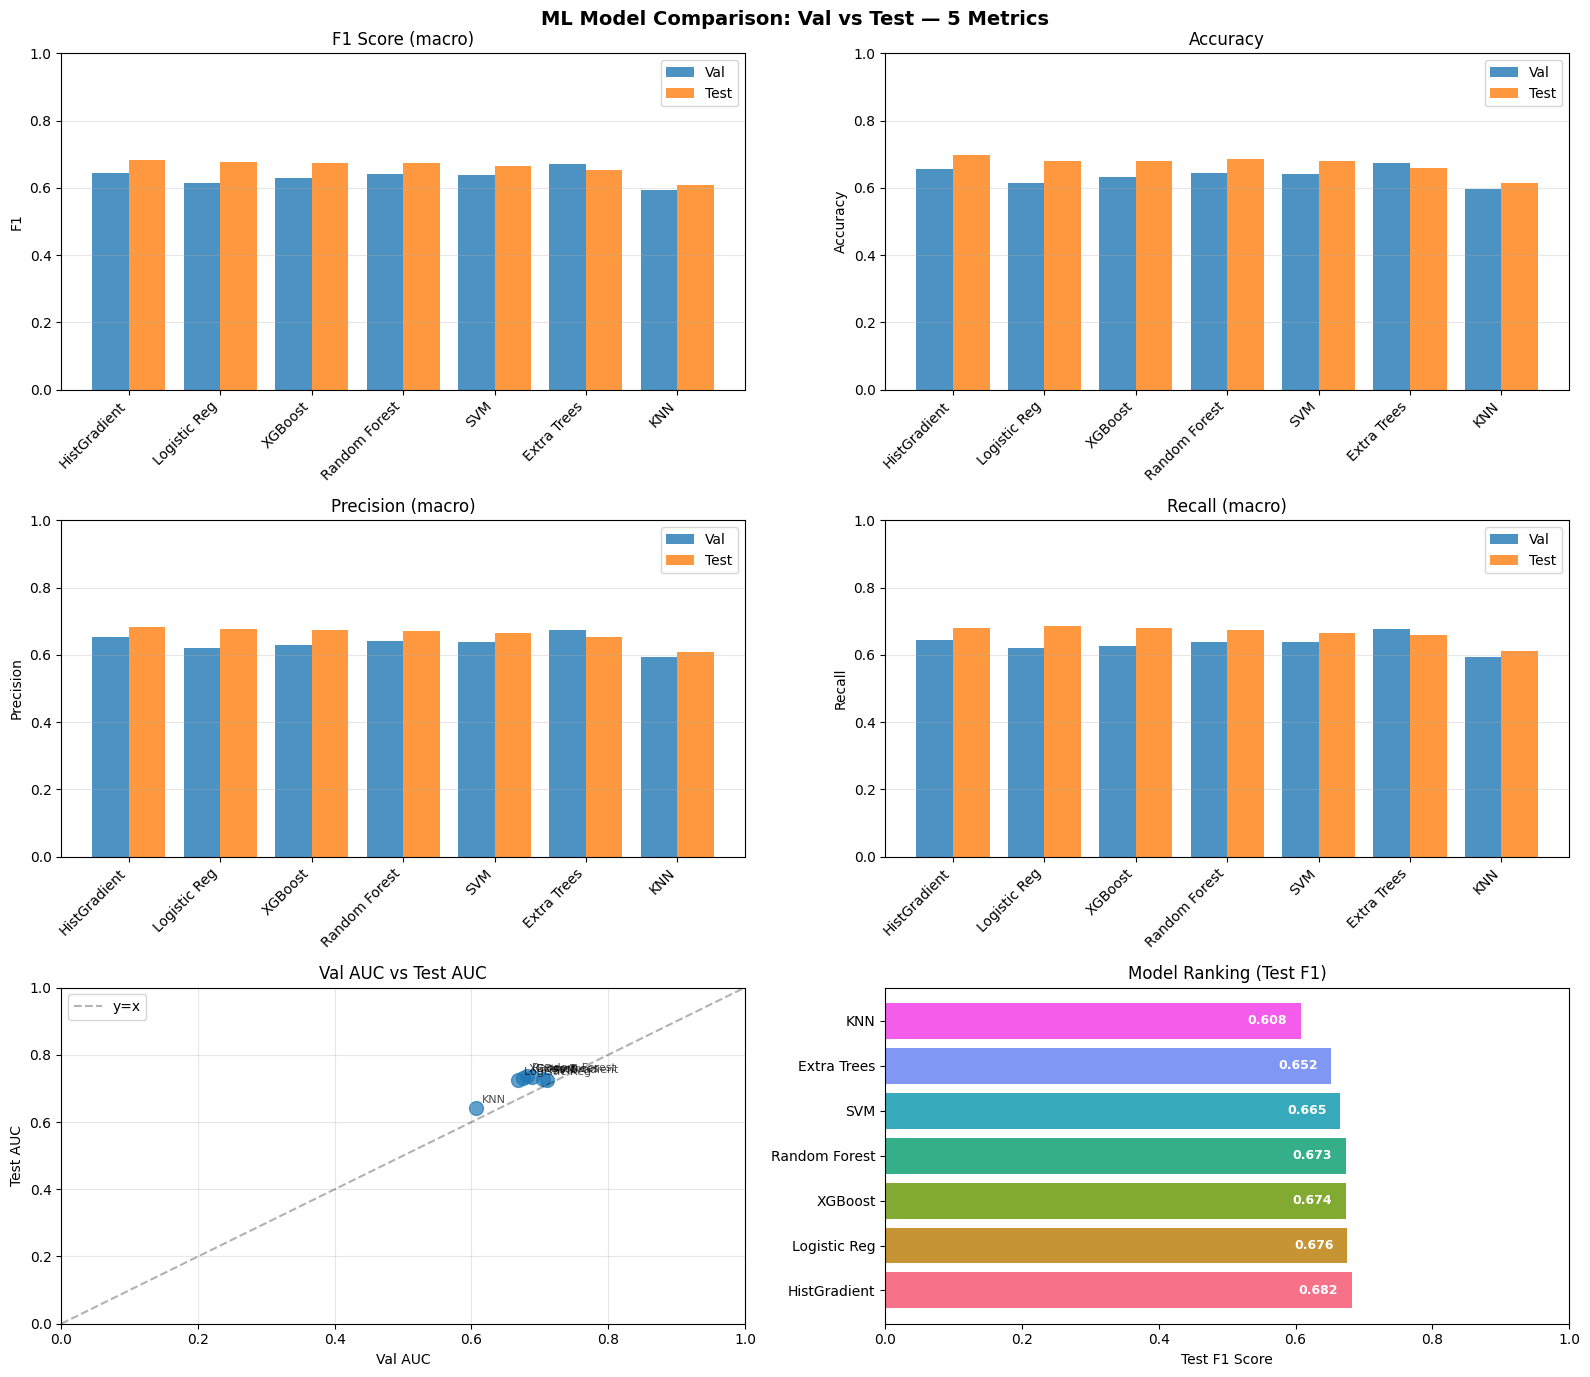

In [22]:
# ============================================
# BƯỚC 6: RESULTS SUMMARY & VISUALIZATION
# ============================================
print("\n" + "="*60)
print("BƯỚC 6: RESULTS SUMMARY")
print("="*60)

df_results        = pd.DataFrame(results_summary)
df_results_sorted = df_results.sort_values("Test f1", ascending=False)

# In bảng đầy đủ cả 5 metrics
print("\n📊 TOP MODELS (sorted by Test f1):")
print(df_results_sorted[[
    "Model",
    "CV f1",
    "Val f1", "Val Precision", "Val Recall", "Val AUC",
    "Test f1", "Test Precision", "Test Recall", "Test AUC",
]].to_string(index=False))

# Save CSV
csv_path = os.path.join(OUTPUT_DIR, "results_summary.csv")
df_results_sorted.to_csv(csv_path, index=False)
print(f"\n💾 Results saved to: {csv_path}")


# ============================================
# VISUALIZATION  (3×2 = 6 charts)
# ============================================
print("\n" + "="*60)
print("CREATING VISUALIZATIONS...")
print("="*60)

fig, axes = plt.subplots(3, 2, figsize=(16, 14))
fig.suptitle("ML Model Comparison: Val vs Test — 5 Metrics", fontsize=14, fontweight="bold")

x_pos  = np.arange(len(df_results_sorted))
labels = df_results_sorted["Model"]
ticks_kwargs = dict(rotation=45, ha="right")

# ── helper: vẽ 1 grouped bar chart ──
def grouped_bar(ax, val_col, test_col, title, ylabel):
    ax.bar(x_pos - 0.2, df_results_sorted[val_col],  0.4, label=f"Val",  alpha=0.8)
    ax.bar(x_pos + 0.2, df_results_sorted[test_col], 0.4, label=f"Test", alpha=0.8)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(labels, **ticks_kwargs)
    ax.legend()
    ax.set_ylim(0, 1)
    ax.grid(axis="y", alpha=0.3)

# Plot 1: F1
grouped_bar(axes[0, 0], "Val f1", "Test f1", "F1 Score (macro)", "F1")

# Plot 2: Accuracy
grouped_bar(axes[0, 1], "Val Acc", "Test Acc", "Accuracy", "Accuracy")

# Plot 3: Precision  ← MỚI
grouped_bar(axes[1, 0], "Val Precision", "Test Precision", "Precision (macro)", "Precision")

# Plot 4: Recall  ← MỚI
grouped_bar(axes[1, 1], "Val Recall", "Test Recall", "Recall (macro)", "Recall")

# Plot 5: AUC scatter
ax = axes[2, 0]
ax.scatter(df_results_sorted["Val AUC"], df_results_sorted["Test AUC"], s=100, alpha=0.7)
for i, txt in enumerate(labels):
    ax.annotate(txt,
                (df_results_sorted["Val AUC"].iloc[i], df_results_sorted["Test AUC"].iloc[i]),
                fontsize=8, alpha=0.7, xytext=(4, 4), textcoords="offset points")
ax.plot([0, 1], [0, 1], "k--", alpha=0.3, label="y=x")
ax.set_xlabel("Val AUC")
ax.set_ylabel("Test AUC")
ax.set_title("Val AUC vs Test AUC")
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.legend(); ax.grid(alpha=0.3)

# Plot 6: Radar-style ranking (Test F1 horizontal bar)
ax = axes[2, 1]
colors = sns.color_palette("husl", len(df_results_sorted))
bars = ax.barh(df_results_sorted["Model"], df_results_sorted["Test f1"], color=colors)
ax.set_xlabel("Test F1 Score")
ax.set_title("Model Ranking (Test F1)")
ax.set_xlim(0, 1)
for bar in bars:
    w = bar.get_width()
    ax.text(w - 0.02, bar.get_y() + bar.get_height() / 2,
            f"{w:.3f}", ha="right", va="center",
            fontweight="bold", color="white", fontsize=9)

plt.tight_layout()
fig_path = os.path.join(OUTPUT_DIR, "model_comparison.png")
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
print(f"✅ Chart saved: {fig_path}")
plt.show()


CONFUSION MATRICES (Top 5 Models)
✅ Confusion matrices saved: /trained/confusion_matrices.png


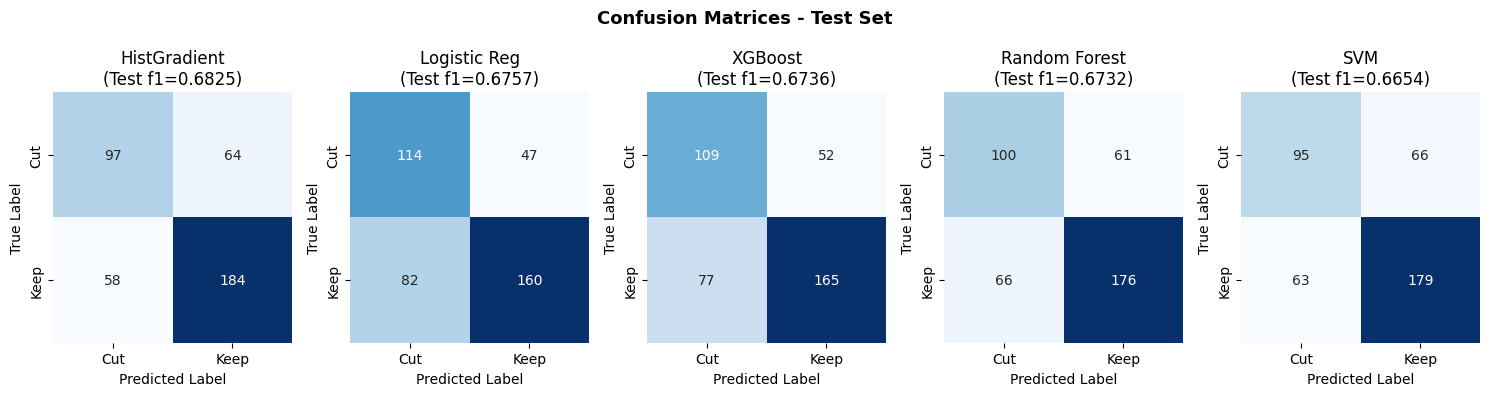


✅ TRAINING COMPLETE!
Output directory: /trained
  - Models: best_*.pkl
  - Results: results_summary.csv
  - Charts: model_comparison.png, confusion_matrices.png


In [23]:
# ============================================
# CONFUSION MATRICES (Top 5 models)
# ============================================
print("\n" + "="*60)
print("CONFUSION MATRICES (Top 5 Models)")
print("="*60)
 
top_3_models = df_results_sorted.head(5)["Model"].values
fig, axes = plt.subplots(1, 5, figsize=(15, 4))
fig.suptitle("Confusion Matrices - Test Set", fontsize=13, fontweight="bold")
 
for idx, model_name in enumerate(top_3_models):
    model = best_models[model_name]
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
 
    ax = axes[idx]
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax, cbar=False,
                xticklabels=["Cut", "Keep"], yticklabels=["Cut", "Keep"])
    f1_val = next(r['Test f1'] for r in results_summary if r['Model'] == model_name)
    ax.set_title(f"{model_name}\n(Test f1={f1_val:.4f})")
    ax.set_ylabel("True Label")
    ax.set_xlabel("Predicted Label")
 
plt.tight_layout()
cm_path = os.path.join(OUTPUT_DIR, "confusion_matrices.png")
plt.savefig(cm_path, dpi=150, bbox_inches="tight")
print(f"✅ Confusion matrices saved: {cm_path}")
plt.show()
 
print("\n" + "="*60)
print("✅ TRAINING COMPLETE!")
print("="*60)
print(f"Output directory: {OUTPUT_DIR}")
print(f"  - Models: best_*.pkl")
print(f"  - Results: results_summary.csv")
print(f"  - Charts: model_comparison.png, confusion_matrices.png")

In [24]:
f1_val = next(r['Test f1'] for r in results_summary if r['Model'] == 'KNN')

f1_val

0.6078

In [25]:
import os
import shutil

source_dir = '/trained'
target_dir = '/kaggle/working'

# Kiểm tra xem thư mục nguồn có tồn tại không
if os.path.exists(source_dir):
    # Lấy danh sách tất cả các file trong /trained
    files = os.listdir(source_dir)
    
    for f in files:
        source_path = os.path.join(source_dir, f)
        target_path = os.path.join(target_dir, f)
        
        # Di chuyển file (hoặc dùng shutil.copy2 nếu muốn giữ lại bản gốc ở /trained)
        shutil.move(source_path, target_path)
        print(f"✅ Moved: {f} -> {target_dir}")
else:
    print("❌ Thư mục /trained không tồn tại!")

✅ Moved: results_summary.csv -> /kaggle/working
✅ Moved: model_comparison.png -> /kaggle/working
✅ Moved: confusion_matrices.png -> /kaggle/working
